In [1]:
import pandas as pd
from pybedtools import BedTool

In [29]:
# loading the merged loops file
mega_loop = pd.read_csv("/usr/users/papantonis1/aman/microc_project/loop_calling_premade_hic/merged_loops_3tools/megalooplist/mega_merged_loops_ctrl.bedpe", sep="\t", header=None, names=["chr1", "start1", "end1", "chr2", "start2", "end2"])

In [30]:
h3ac_bed = BedTool("/usr/users/papantonis1/aman/microc_project/loop_calling_premade_hic/DLD1_H3K27Ac.bed")

In [31]:
h3ac_bed.head()

chr1	7335088	7335173	DRX013177.10_peak_1	316	.	18.39989	37.15107	31.68554	42
 chr1	7961015	7961142	DRX013177.10_peak_2	151	.	9.07507	19.81679	15.19566	70
 chr1	8155162	8155254	DRX013177.10_peak_3	258	.	15.39555	31.10312	25.88550	56
 chr1	11099092	11099184	DRX013177.10_peak_4	158	.	10.44139	20.53890	15.87489	74
 chr1	16514354	16514442	DRX013177.10_peak_5	296	.	13.89532	34.98419	29.60684	41
 chr1	16613378	16613482	DRX013177.10_peak_6	204	.	8.64486	25.43678	20.47946	55
 chr1	16644496	16644578	DRX013177.10_peak_7	153	.	8.28893	19.94592	15.31756	34
 chr1	16740359	16740441	DRX013177.10_peak_8	161	.	9.95685	20.79586	16.11595	19
 chr1	23979210	23979296	DRX013177.10_peak_9	300	.	11.36951	35.49564	30.09096	59
 chr1	24707774	24707856	DRX013177.10_peak_10	297	.	17.07734	35.18681	29.80000	44
 

In [32]:
ac27_bed = h3ac_bed.to_dataframe()

In [33]:
(ac27_bed.end - ac27_bed.start).describe()

count     620.000000
mean      126.087097
std       115.148954
min        82.000000
25%        86.000000
50%       101.500000
75%       128.000000
max      1950.000000
dtype: float64

In [34]:
anchor1_df = mega_loop[["chr1", "start1", "end1"]].copy()
anchor1_df["idx"] = anchor1_df.index
anchor1 = BedTool.from_dataframe(anchor1_df)

In [35]:
anchor2_df = mega_loop[["chr2", "start2", "end2"]].copy()
anchor2_df["idx"] = anchor2_df.index
anchor2 = BedTool.from_dataframe(anchor2_df)

In [36]:
#anchor1.head()

In [37]:
anchor1_cohesin = anchor1.intersect(h3ac_bed, wa=True)
anchor2_cohesin = anchor2.intersect(h3ac_bed, wa=True)

In [38]:
print(anchor1_cohesin)

chr1	28245000	28250000	122
chr1	28245000	28250000	123
chr1	227312500	227317500	967
chr10	5442500	5447500	1081
chr11	1702500	1707500	1648
chr12	10612500	10617500	2318
chr12	71662500	71667500	2631
chr12	89822500	89827500	2695
chr13	23795000	23800000	2916
chr14	59952500	59957500	3377
chr14	100895000	100900000	3567
chr17	6912500	6917500	4266
chr18	8882500	8887500	4686
chr18	9335000	9340000	4687
chr2	58045000	58050000	5460
chr2	216105000	216110000	6128
chr4	39525000	39530000	7814
chr4	74445000	74450000	7940
chr4	110515000	110520000	8124
chr4	169620000	169625000	8361
chr5	127872500	127877500	8870
chr5	131162500	131167500	8881
chr5	131162500	131167500	8881
chr5	131160000	131165000	8882
chr5	131160000	131165000	8882
chr6	26172500	26177500	9272
chr6	26172500	26177500	9273
chr6	38792500	38797500	9340
chr6	38795000	38800000	9341
chr6	52282500	52287500	9415
chr7	20212500	20217500	10036
chr7	92692500	92697500	10299
chr8	127215000	127220000	11108
chr8	127215000	127220000	11109
chr9	20550000	20555000

In [39]:
anchor1_idx = set(int(f.fields[3]) for f in anchor1_cohesin)
anchor2_idx = set(int(f.fields[3]) for f in anchor2_cohesin)

In [40]:
common_idx = sorted(anchor1_idx & anchor2_idx) # both anchor overlap
common_idx

[15847]

In [41]:
mega_loop.iloc[common_idx].to_csv("h3k27ac_associated_loops_bothanchoroverlap_ctrl.bedpe", sep="\t", index=False, header=False)

In [42]:
len(mega_loop.iloc[common_idx])

1

In [43]:
either_idx = sorted(anchor1_idx | anchor2_idx) # either or
mega_loop.iloc[either_idx].to_csv("h3k27ac_associated_loops_eitheranchoroverlap_ctrl.bedpe", sep="\t", index=False, header=False)


In [44]:
len(mega_loop.iloc[either_idx])

92

In [45]:
g_path = "/usr/users/papantonis1/aman/microc_project/refgen/hg38.genome"

anchor1_slop = BedTool.from_dataframe(anchor1_df).slop(b=2000, g=g_path)
anchor2_slop = BedTool.from_dataframe(anchor2_df).slop(b=2000, g=g_path)

In [46]:
anchor1_slop_h3k3 = anchor1_slop.intersect(h3ac_bed, wa=True)
anchor2_slop_h3k3 = anchor2_slop.intersect(h3ac_bed, wa=True)

In [47]:
anchor1_slop_h3k3_df = anchor1_slop_h3k3.to_dataframe(names=["chr", "start", "end", "idx"])
anchor2_slop_h3k3_df = anchor2_slop_h3k3.to_dataframe(names=["chr", "start", "end", "idx"])

anchor1_slop_idx = anchor1_slop_h3k3_df["idx"].astype(int).tolist()
anchor2_slop_idx = anchor2_slop_h3k3_df["idx"].astype(int).tolist()

In [48]:
anchor1_slop_idx = set(int(f.fields[3]) for f in anchor1_slop_h3k3)
anchor2_slop_idx = set(int(f.fields[3]) for f in anchor2_slop_h3k3)

In [49]:
common_slop_idx = sorted(anchor1_slop_idx & anchor2_slop_idx) # both anchor overlap
#common_slop_idx

In [50]:
mega_loop.iloc[common_slop_idx].to_csv("slop2kb_h3k27ac_associated_loops_bothanchoroverlap_ctrl.bedpe", sep="\t", index=False, header=False)

In [51]:
len(mega_loop.iloc[common_slop_idx])

2

In [52]:
either_slop_idx = sorted(anchor1_slop_idx | anchor2_slop_idx) # either or
mega_loop.iloc[either_slop_idx].to_csv("slop2kb_h3k27ac_associated_loops_eitheranchoroverlap_ctrl.bedpe", sep="\t", index=False, header=False)

In [53]:
len(mega_loop.iloc[either_slop_idx])

175

In [54]:
h_bed = h3ac_bed.to_dataframe()
h_bed["width"] = h_bed["end"] - h_bed["start"]
h_bed["width"].describe()

count     620.000000
mean      126.087097
std       115.148954
min        82.000000
25%        86.000000
50%       101.500000
75%       128.000000
max      1950.000000
Name: width, dtype: float64

def classify_slop(idx):
    if idx in anchor1_slop_idx and idx in anchor2_slop_idx:
        return "both_anchors"
    elif idx in anchor1_slop_idx:
        return "anchor1_only"
    elif idx in anchor2_slop_idx:
        return "anchor2_only"
    else:
        return "none"

mega_loop["h3k27me3_overlap_slop2kb"] = mega_loop.index.map(classify_slop)

mega_loop.to_csv("ctrl_loops_h3k27me3_annotated_slop2kb.bedpe", sep="\t", index=False, header=False)

mega_loop

mega_loop["h3k27me3_overlap_slop2kb"].value_counts()

num_slop_h3k27me3_loops = (mega_loop["h3k27me3_overlap_slop2kb"] != "none").sum()
print(num_slop_h3k27me3_loops)

In [3]:
stripe_ctrl = pd.read_csv("/usr/users/papantonis1/aman/microc_project/loop_calling_premade_hic/stripenn/result_filtered.tsv", sep='\t')
stripe_ctrl

,chr,pos1,pos2,chr2,pos3,pos4,length,width,Mean,maxpixel,pvalue,Stripiness
0,chr16,34575001,34595000,chr16,34575001,36340000,1765000,20000,71.705793,95.0%,0.0010,1793.218818
1,chr16,34575001,34600000,chr16,33515001,34600000,1085000,25000,109.832609,95.0%,0.0010,131.124773
2,chr20,31055001,31075000,chr20,29505001,31075000,1570000,20000,30.604464,98.0%,0.0020,60.741310
3,chr2,90380001,90400000,chr2,89190001,90400000,1210000,20000,87.110526,95.0%,0.0010,50.988033
4,chr20,31055001,31080000,chr20,31055001,31385000,330000,25000,126.087719,99.0%,0.0010,47.146748
...,...,...,...,...,...,...,...,...,...,...,...,...
2603,chr9,83530001,83545000,chr9,83200001,83545000,345000,15000,15.057971,95.0%,0.0960,-5.165028
2604,chr10,41875001,41900000,chr10,41730001,41900000,170000,25000,105.552941,95.0%,0.0110,-5.557532
2605,chr2,36355001,36375000,chr2,36355001,36785000,430000,20000,20.095930,95.0%,0.0635,-6.039169
2606,chr1,94515001,94550000,chr1,94515001,94745000,230000,35000,34.860248,98.0%,0.0640,-7.465436


In [9]:
mean_series = (stripe_ctrl["pos2"] - stripe_ctrl["pos1"]) / 2000
mean_df = mean_series.to_frame(name="mean_pos")
mean_df

,mean_pos
0,9.9995
1,12.4995
2,9.9995
3,9.9995
4,12.4995
...,...
2603,7.4995
2604,12.4995
2605,9.9995
2606,17.4995


In [13]:
stripe_ctrl["length"].describe()

count    2.608000e+03
mean     3.967159e+05
std      2.082995e+05
min      1.150000e+05
25%      2.500000e+05
50%      3.450000e+05
75%      4.850000e+05
max      1.765000e+06
Name: length, dtype: float64

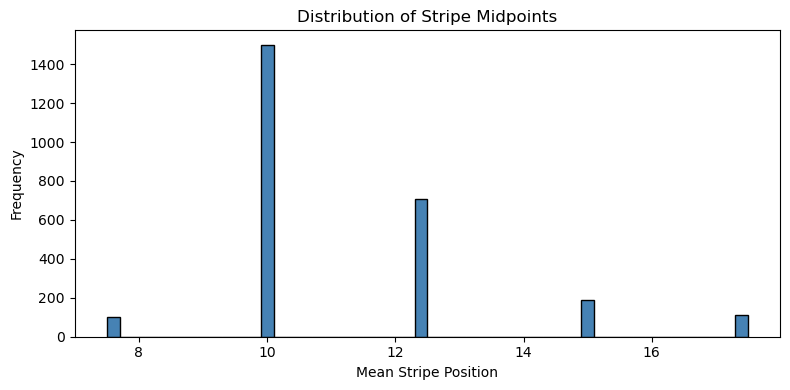

In [11]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 4))
plt.hist(mean_df["mean_pos"], bins=50, color='steelblue', edgecolor='black')
plt.xlabel("Mean Stripe Position")
plt.ylabel("Frequency")
plt.title("Distribution of Stripe Midpoints")
#plt.grid(True)
plt.tight_layout()
plt.show()

In [12]:
# loading the merged loops file
mega_loop = pd.read_csv("/usr/users/papantonis1/aman/microc_project/loop_calling_premade_hic/merged_loops_3tools/megalooplist/mega_merged_loops_ctrl.bedpe", sep="\t", header=None, names=["chr1", "start1", "end1", "chr2", "start2", "end2"])
mega_loop

,chr1,start1,end1,chr2,start2,end2
0,chr1,3912500,3917500,chr1,4592500,4597500
1,chr1,5502500,5507500,chr1,5622500,5627500
2,chr1,5502500,5507500,chr1,5742500,5747500
3,chr1,5632500,5637500,chr1,5742500,5747500
4,chr1,5635000,5640000,chr1,5980000,5985000
...,...,...,...,...,...,...
19031,chrY,10992500,10997500,chrY,11722500,11727500
19032,chrY,11302500,11307500,chrY,11722500,11727500
19033,chrY,11522500,11527500,chrY,11712500,11717500
19034,chrY,11525000,11530000,chrY,11680000,11685000
